In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator



In [2]:
# diagonalization
A = np.array([[2, 1],
              [1, 3]])

w, v = np.linalg.eigh(A)
print(w)
print(v)


[1.38196601 3.61803399]
[[-0.85065081  0.52573111]
 [ 0.52573111  0.85065081]]


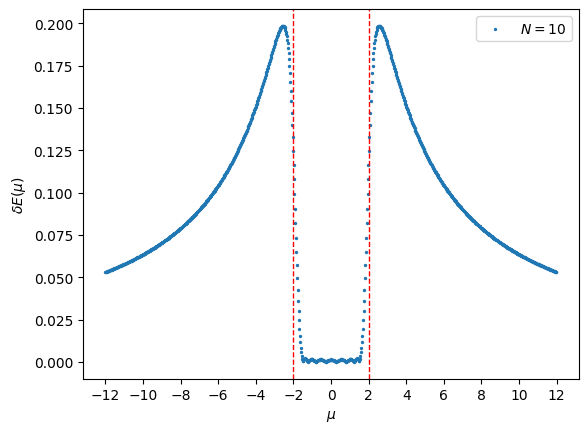

In [23]:
t = 1
N_list = [10]
Delta = 0.6

eps_abs_max = 12.0
steps = 1000

fig, ax = plt.subplots()
colors = plt.get_cmap("tab10").colors

for num, N in enumerate(N_list):
    eps_list = []
    dE_list = []
    weight_list = []
    for step in range(0, steps):

        eps = -eps_abs_max + 2*eps_abs_max*step/steps 
        eps_list.append(eps)
        i = np.arange(N-1)

        A = np.zeros((N, N)) 
        A[i, i] = - eps  
        A[i, i+1] = - t 
        A[i+1, i] = - t 

        B = np.zeros((N, N))
        B[i+1, i] = - Delta
        B[i, i+1] = Delta

        H = np.block([
        [A, B],
        [-B.conjugate().T, -A.conjugate().T]
        ])

        w, v = np.linalg.eigh(H)
        # print(w)
        # print(v[N])
        dE = w[N]
        dE_list.append(dE)
        weight_list.append([(np.abs(v[N][j])**2 + np.abs(v[N][j+N])**2) for j in range(N)])
    ax.scatter(eps_list, dE_list, s=2, label=f'$N={N}$', color=colors[num])

ax.axvline(x=+2, color='red', linestyle='--', linewidth=1)
ax.axvline(x=-2, color='red', linestyle='--', linewidth=1)

ax.set_xlabel(r"$\mu$")
ax.set_ylabel(r"$\delta E(\mu)$")
# ax.set_yscale("log")
ax.xaxis.set_major_locator(MultipleLocator(2))
ax.legend()

plt.show()

In [24]:
print(weight_list[0])

[np.float64(0.01792375041287475), np.float64(0.06538263200124782), np.float64(0.1254106245219525), np.float64(0.17620738008231449), np.float64(0.19891083802628123), np.float64(0.18435419968443761), np.float64(0.13689497524699473), np.float64(0.07402217948705528), np.float64(0.020859820495613586), np.float64(3.3600041227789666e-05)]


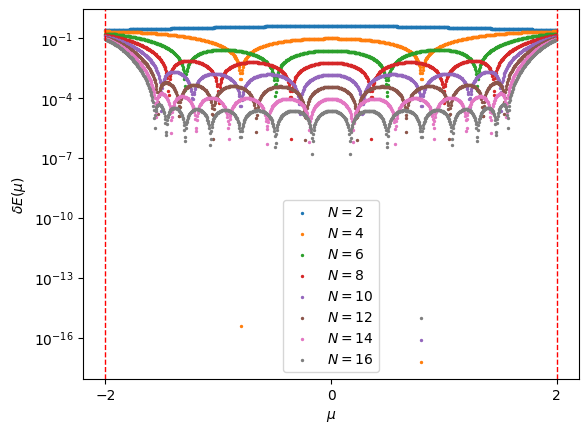

In [ ]:
t = 1
N_list = [2,4,6,8,10,12,14,16]
Delta = 0.6

eps_abs_max = 2.0
steps = 1000

fig, ax = plt.subplots()
colors = plt.get_cmap("tab10").colors

for num, N in enumerate(N_list):
    eps_list = []
    dE_list = []
    weight_list = []
    for step in range(0, steps):

        eps = -eps_abs_max + 2*eps_abs_max*step/steps 
        eps_list.append(eps)
        i = np.arange(N-1)

        A = np.zeros((N, N)) 
        A[i, i] = - eps  
        A[i, i+1] = - t 
        A[i+1, i] = - t 

        B = np.zeros((N, N))
        B[i+1, i] = - Delta
        B[i, i+1] = Delta

        H = np.block([
        [A, B],
        [-B.conjugate().T, -A.conjugate().T]
        ])

        w, v = np.linalg.eigh(H)
        # print(w)
        # print(v)
        dE = w[N]
        dE_list.append(dE)
        # weight_list.append(v[N])
    ax.scatter(eps_list, dE_list, s=2, label=f'$N={N}$', color=colors[num])

ax.axvline(x=+2, color='red', linestyle='--', linewidth=1)
ax.axvline(x=-2, color='red', linestyle='--', linewidth=1)

ax.set_xlabel(r"$\mu$")
ax.set_ylabel(r"$\delta E(\mu)$")
ax.set_yscale("log")  # y軸を対数にする
ax.xaxis.set_major_locator(MultipleLocator(2))
ax.legend()

plt.show()